In [2]:
import requests

In [3]:
endpoint = "https://www.themealdb.com/api/json/v1/1/categories.php"
respuesta = requests.get(endpoint, timeout=10)
respuesta.status_code

200

In [5]:
datos = respuesta.json()
print(datos)
datos.keys()
datos

{'categories': [{'idCategory': '1', 'strCategory': 'Beef', 'strCategoryThumb': 'https://www.themealdb.com/images/category/beef.png', 'strCategoryDescription': 'Beef is the culinary name for meat from cattle, particularly skeletal muscle. Humans have been eating beef since prehistoric times.[1] Beef is a source of high-quality protein and essential nutrients.[2]'}, {'idCategory': '2', 'strCategory': 'Chicken', 'strCategoryThumb': 'https://www.themealdb.com/images/category/chicken.png', 'strCategoryDescription': 'Chicken is a type of domesticated fowl, a subspecies of the red junglefowl. It is one of the most common and widespread domestic animals, with a total population of more than 19 billion as of 2011.[1] Humans commonly keep chickens as a source of food (consuming both their meat and eggs) and, more rarely, as pets.'}, {'idCategory': '3', 'strCategory': 'Dessert', 'strCategoryThumb': 'https://www.themealdb.com/images/category/dessert.png', 'strCategoryDescription': 'Dessert is a co

{'categories': [{'idCategory': '1',
   'strCategory': 'Beef',
   'strCategoryThumb': 'https://www.themealdb.com/images/category/beef.png',
   'strCategoryDescription': 'Beef is the culinary name for meat from cattle, particularly skeletal muscle. Humans have been eating beef since prehistoric times.[1] Beef is a source of high-quality protein and essential nutrients.[2]'},
  {'idCategory': '2',
   'strCategory': 'Chicken',
   'strCategoryThumb': 'https://www.themealdb.com/images/category/chicken.png',
   'strCategoryDescription': 'Chicken is a type of domesticated fowl, a subspecies of the red junglefowl. It is one of the most common and widespread domestic animals, with a total population of more than 19 billion as of 2011.[1] Humans commonly keep chickens as a source of food (consuming both their meat and eggs) and, more rarely, as pets.'},
  {'idCategory': '3',
   'strCategory': 'Dessert',
   'strCategoryThumb': 'https://www.themealdb.com/images/category/dessert.png',
   'strCategor

In [6]:
import pandas as pd
menu = pd.DataFrame(datos["categories"])
menu.head()

,idCategory,strCategory,strCategoryThumb,strCategoryDescription
0,1,Beef,https://www.themealdb.com/images/category/beef...,Beef is the culinary name for meat from cattle...
1,2,Chicken,https://www.themealdb.com/images/category/chic...,"Chicken is a type of domesticated fowl, a subs..."
2,3,Dessert,https://www.themealdb.com/images/category/dess...,Dessert is a course that concludes a meal. The...
3,4,Lamb,https://www.themealdb.com/images/category/lamb...,"Lamb, hogget, and mutton are the meat of domes..."
4,5,Miscellaneous,https://www.themealdb.com/images/category/misc...,General foods that don't fit into another cate...


In [7]:
def extract_menu_mundial():
    url = "https://www.themealdb.com/api/json/v1/1/categories.php"
    try:
        datos = requests.get(url, timeout=10).json()
        return pd.DataFrame(datos["categories"])[["strCategory"]]
    except Exception:
        print("Error al obtener el menú mundial")
        return pd.DataFrame()

In [8]:
menu = extract_menu_mundial()
menu["strCategory"].tolist()

['Beef',
 'Chicken',
 'Dessert',
 'Lamb',
 'Miscellaneous',
 'Pasta',
 'Pork',
 'Seafood',
 'Side',
 'Starter',
 'Vegan',
 'Vegetarian',
 'Breakfast',
 'Goat']

In [ ]:
print("Categorias del mundo: ", len(menu))

Categorias del mundo:  14


# Leyendo del Archivo 


In [10]:
pedidos = pd.read_csv("rappi_pedidos.csv")
pedidos.shape   
for lote in pd.read_csv("rappi_pedidos.csv", chunksize=500):
    print("Procesando lote de", len(lote), "filas")

Procesando lote de 500 filas
Procesando lote de 500 filas
Procesando lote de 207 filas


In [11]:
catalogo = pd.read_csv("catalogo_platos.csv")
pedidos = pd.read_csv("rappi_pedidos.csv")
prueba = pedidos.merge(catalogo, on="id_plato", how="left")
prueba["categoria"].notna().sum()

np.int64(1111)

In [12]:
prueba[prueba["categoria"].isna()]["id_plato"].unique()[:5]

<StringArray>
[' P0202', ' P0201', ' P0601', ' P0102', ' P0101']
Length: 5, dtype: str

In [13]:
def extract_pedidos(ruta):
    df = pd.read_csv(ruta)
    print(f"Extraídos {df.shape[0]} pedidos")
    return df

In [14]:
pedidos = extract_pedidos("rappi_pedidos.csv")

Extraídos 1207 pedidos


In [ ]:
(pedidos["estado"] == "cancelado").sum()
#(pedidos["estado"] == " cancelado").sum()
#(pedidos["estado"] == "CANCELADO").sum()
#(pedidos["estado"] == " CANCELADO").sum()
#(pedidos["estado"] == " Cancelado").sum()

np.int64(34)

In [16]:
pedidos["estado"].nunique()

12

In [17]:
pedidos["estado"] = pedidos["estado"].astype(str).str.strip().str.lower()
sorted(pedidos["estado"].unique())

['cancelado', 'en_camino', 'entregado']

In [18]:
(pedidos["estado"] == "cancelado").sum()

np.int64(117)

In [19]:
pedidos["ciudad"] = (pedidos["ciudad"].astype(str).str.strip().str.lower()
                     .str.normalize("NFKD")
                     .str.encode("ascii", "ignore").str.decode("utf-8")
                     .str.capitalize())
sorted(pedidos["ciudad"].unique())

['Barranquilla', 'Bogota', 'Cali', 'Cartagena', 'Medellin']

In [20]:
import numpy as np
pedidos["minutos_entrega"] = pd.to_numeric(pedidos["minutos_entrega"], errors="coerce")
pedidos.loc[(pedidos["minutos_entrega"] <= 0) | (pedidos["minutos_entrega"] > 180),
            "minutos_entrega"] = np.nan
pedidos["minutos_entrega"] = pedidos["minutos_entrega"].fillna(pedidos["minutos_entrega"].median())

In [22]:
pedidos["propina_usd"] = pd.to_numeric(pedidos["propina_usd"], errors="coerce").fillna(0)

In [23]:
pedidos = pedidos.dropna(subset=["id_pedido"]).drop_duplicates()
pedidos.shape

(1197, 7)

In [25]:
pedidos["id_plato"] = pedidos["id_plato"].astype(str).str.strip()

In [21]:
def transform(pedidos, catalogo):
    pedidos["estado"] = pedidos["estado"].astype(str).str.strip().str.lower()
    pedidos["ciudad"] = (pedidos["ciudad"].astype(str).str.strip().str.lower()
                         .str.normalize("NFKD")
                         .str.encode("ascii", "ignore").str.decode("utf-8")
                         .str.capitalize())
    pedidos["propina_usd"] = pd.to_numeric(pedidos["propina_usd"], errors="coerce").fillna(0)
    pedidos["minutos_entrega"] = pd.to_numeric(pedidos["minutos_entrega"], errors="coerce")
    pedidos.loc[(pedidos["minutos_entrega"] <= 0) | (pedidos["minutos_entrega"] > 180),
                "minutos_entrega"] = np.nan
    pedidos["minutos_entrega"] = pedidos["minutos_entrega"].fillna(pedidos["minutos_entrega"].median())
    pedidos = pedidos.dropna(subset=["id_pedido"]).drop_duplicates()
    pedidos["id_plato"] = pedidos["id_plato"].astype(str).str.strip()
    final = pedidos.merge(catalogo, on="id_plato", how="left")
    final["categoria"] = final["categoria"].fillna("Desconocido")
    return final

In [26]:
catalogo = pd.read_csv("catalogo_platos.csv")
final = transform(pedidos, catalogo)
(final["categoria"] == "Desconocido").sum() 

np.int64(0)

In [27]:
final["categoria"].value_counts()

categoria
Chicken       479
Beef          272
Side          190
Pasta         121
Seafood       109
Lamb           11
Dessert        10
Vegetarian      5
Name: count, dtype: int64

In [28]:
(final["categoria"].value_counts(normalize=True)* 100).round(1)

categoria
Chicken       40.0
Beef          22.7
Side          15.9
Pasta         10.1
Seafood        9.1
Lamb           0.9
Dessert        0.8
Vegetarian     0.4
Name: proportion, dtype: float64

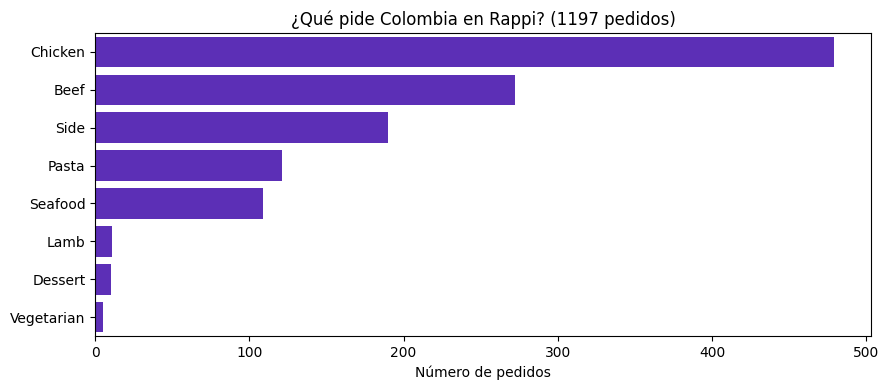

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

orden = final["categoria"].value_counts().index
plt.figure(figsize=(9, 4))
sns.countplot(data=final, y="categoria", order=orden, color="#5418CC")
plt.title("¿Qué pide Colombia en Rappi? (1197 pedidos)")
plt.xlabel("Número de pedidos")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [30]:
proteina = ["Beef", "Chicken", "Seafood", "Lamb"]
pct_proteina = final["categoria"].isin(proteina).mean() * 100
round(pct_proteina, 1)

np.float64(72.8)

In [31]:
mundiales = set(menu["strCategory"])
pedidas = set(final[final["categoria"] != "Desconocido"]["categoria"])
nunca_pedidas = mundiales - pedidas
print("Existen en el mundo pero Colombia no ofrece:")
print(sorted(nunca_pedidas), "->", len(nunca_pedidas), "categorías")

Existen en el mundo pero Colombia no ofrece:
['Breakfast', 'Goat', 'Miscellaneous', 'Pork', 'Starter', 'Vegan'] -> 6 categorías
